# GeoWatch — Phase 7: Vegetation Decline Monitoring

Demonstrates the vegetation-change detection engine built on top of the
Milestone 1 NDVI foundation: `compute_dndvi()`
(`src/remote_sensing/ndvi.py`) and `analyze_vegetation_change()`
(`src/detection/vegetation.py`).

**Why this notebook uses a synthetic scene, same as Milestone 2's
wildfire notebook did before Milestone 3 added real data:** GeoWatch
does not yet have a live optical-imagery provider (Sentinel-2/Landsat
ingestion is still roadmap — NASA FIRMS, the one real data source
GeoWatch has, provides fire-hotspot points, not the raw spectral bands
vegetation analysis needs). This notebook validates the detection
engine against known ground truth. There is deliberately **no
Vegetation Monitor tab in the dashboard yet** — adding one without a
real data source behind it would misrepresent the system's actual
capability, which runs against this project's own Responsible Use
principle.

Pipeline demonstrated:

```
bands (NIR, RED), two time points -> NDVI (each) -> dNDVI -> decline mask + classification
```


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from src.remote_sensing.ndvi import compute_ndvi, compute_dndvi
from src.detection.vegetation import (
    analyze_vegetation_change,
    VegetationChangeClass,
    VegetationChangeThresholds,
)


## 1. Build a synthetic baseline / recent scene

Three regions with known, constructed ground truth:
- **Left third**: stable vegetation (no real change, plus small noise)
- **Middle third**: a *graded* decline (e.g. drought stress or land
  clearing), strongest at the center and fading toward the edges,
  so pixels span multiple severity classes rather than one uniform block
- **Right third**: a graded improvement (e.g. post-fire regrowth, a wet season)

Explicitly synthetic — not a real location.

In [2]:
SIZE = 90
THIRD = SIZE // 3

rng = np.random.default_rng(11)

# Baseline: healthy vegetation everywhere.
nir_baseline = np.clip(0.50 + rng.normal(0, 0.01, (SIZE, SIZE)), 0, 1)
red_baseline = np.clip(0.10 + rng.normal(0, 0.01, (SIZE, SIZE)), 0, 1)

nir_recent = nir_baseline.copy()
red_recent = red_baseline.copy()

# Middle third: a gradient of decline intensity (0 at the boundary, strongest
# at the center) so pixels fall across multiple severity classes -- more
# realistic than a uniform block, and lets the threshold-sensitivity demo
# below actually show a meaningful difference.
decline_cols = np.arange(THIRD, 2 * THIRD)
decline_center = THIRD + (THIRD // 2)
decline_intensity = 1.0 - np.abs(decline_cols - decline_center) / (THIRD / 2)
decline_intensity = np.clip(decline_intensity, 0, 1)
nir_recent[:, THIRD:2*THIRD] -= 0.28 * decline_intensity
red_recent[:, THIRD:2*THIRD] += 0.10 * decline_intensity

# Right third: improvement (post-fire regrowth / wet season), also graded.
improve_cols = np.arange(2 * THIRD, SIZE)
improve_center = 2 * THIRD + (THIRD // 2)
improve_intensity = 1.0 - np.abs(improve_cols - improve_center) / (THIRD / 2)
improve_intensity = np.clip(improve_intensity, 0, 1)
nir_recent[:, 2*THIRD:] += 0.15 * improve_intensity
red_recent[:, 2*THIRD:] -= 0.03 * improve_intensity

nir_recent = np.clip(nir_recent, 0, 1)
red_recent = np.clip(red_recent, 0, 1)

print(f"Scene: {SIZE}x{SIZE}. Left=stable, middle=graded decline, right=graded improvement.")


Scene: 90x90. Left=stable, middle=graded decline, right=graded improvement.


## 2. Compute NDVI, dNDVI, and run the analysis

In [3]:
ndvi_baseline = compute_ndvi(nir_baseline, red_baseline)
ndvi_recent = compute_ndvi(nir_recent, red_recent)
dndvi = compute_dndvi(ndvi_baseline, ndvi_recent)

result = analyze_vegetation_change(dndvi)  # default VegetationChangeThresholds()

print("Vegetation-change thresholds used (dNDVI upper bounds):")
print(f"  improvement_max      = {result.thresholds.improvement_max}")
print(f"  stable_max             = {result.thresholds.stable_max}")
print(f"  slight_decline_max     = {result.thresholds.slight_decline_max}")
print(f"  moderate_decline_max   = {result.thresholds.moderate_decline_max}")
print()
print("Pixel counts per change class:")
for label, count in result.change_counts.items():
    print(f"  {label:18s} {count}")
print()
print(f"Mean NDVI change across scene: {result.mean_ndvi_change:.4f}")


Vegetation-change thresholds used (dNDVI upper bounds):
  improvement_max      = -0.1
  stable_max             = 0.05
  slight_decline_max     = 0.15
  moderate_decline_max   = 0.3

Pixel counts per change class:
  no_data            0
  improvement        853
  stable             4817
  slight_decline     540
  moderate_decline   723
  severe_decline     1167

Mean NDVI change across scene: 0.0665


## 3. Visualize

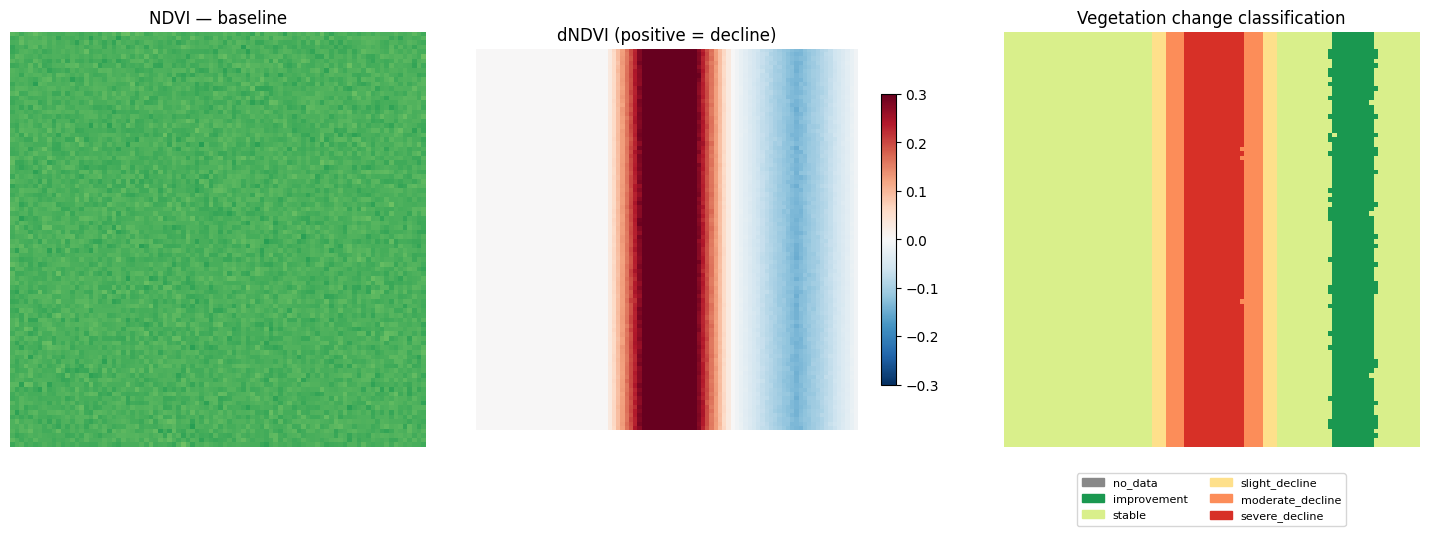

In [4]:
change_colors = {
    VegetationChangeClass.NO_DATA: "#888888",
    VegetationChangeClass.IMPROVEMENT: "#1a9850",
    VegetationChangeClass.STABLE: "#d9ef8b",
    VegetationChangeClass.SLIGHT_DECLINE: "#fee08b",
    VegetationChangeClass.MODERATE_DECLINE: "#fc8d59",
    VegetationChangeClass.SEVERE_DECLINE: "#d73027",
}
change_order = list(change_colors.keys())
change_index = np.vectorize(lambda c: change_order.index(c))(result.change_labels)
cmap = ListedColormap(list(change_colors.values()))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ndvi_baseline, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("NDVI — baseline")
axes[0].axis("off")

im1 = axes[1].imshow(dndvi, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[1].set_title("dNDVI (positive = decline)")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], shrink=0.7)

im2 = axes[2].imshow(change_index, cmap=cmap, vmin=0, vmax=len(change_order) - 1)
axes[2].set_title("Vegetation change classification")
axes[2].axis("off")

legend_patches = [plt.Rectangle((0, 0), 1, 1, color=c) for c in change_colors.values()]
axes[2].legend(
    legend_patches, [c.value for c in change_order], loc="upper center",
    bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=8,
)

plt.tight_layout()
plt.show()


## 4. Threshold sensitivity

Same principle as burn-severity thresholds: what counts as "decline"
is a methodology choice, not a universal fact. This shows the same
scene classified with stricter thresholds.

In [5]:
strict_thresholds = VegetationChangeThresholds(
    improvement_max=-0.05, stable_max=0.02, slight_decline_max=0.08, moderate_decline_max=0.15
)
result_strict = analyze_vegetation_change(dndvi, thresholds=strict_thresholds)

default_decline_pixels = sum(
    v for k, v in result.change_counts.items()
    if k in ("slight_decline", "moderate_decline", "severe_decline")
)
strict_decline_pixels = sum(
    v for k, v in result_strict.change_counts.items()
    if k in ("slight_decline", "moderate_decline", "severe_decline")
)

print(f"Default thresholds  -> {default_decline_pixels} declining pixels "
      f"({100 * default_decline_pixels / dndvi.size:.1f}% of scene)")
print(f"Stricter thresholds -> {strict_decline_pixels} declining pixels "
      f"({100 * strict_decline_pixels / dndvi.size:.1f}% of scene)")


Default thresholds  -> 2430 declining pixels (30.0% of scene)
Stricter thresholds -> 2610 declining pixels (32.2% of scene)


## 5. Feed into an intelligence report

`generate_intelligence_report()` accepts this result directly alongside
(or instead of) a wildfire result — the limitations text adapts
automatically to name the actual thresholds used.

In [6]:
from datetime import datetime, timezone
from src.geospatial.aoi import AOI
from src.reporting.reports import generate_intelligence_report

aoi = AOI(label="Vegetation demo AOI", west=10.0, south=-35.0, east=40.0, north=-10.0)
now = datetime.now(timezone.utc)

report = generate_intelligence_report(
    aoi=aoi, period_start=now, period_end=now, events=[], vegetation_result=result
)

print(f"Mean NDVI change: {report.mean_ndvi_change}")
print(f"Vegetation change breakdown: {report.vegetation_change_breakdown}")
print()
print("Limitations:")
for lim in report.limitations:
    print(f"- {lim}")


Mean NDVI change: 0.0665
Vegetation change breakdown: {'no_data': 0, 'improvement': 853, 'stable': 4817, 'slight_decline': 540, 'moderate_decline': 723, 'severe_decline': 1167}

Limitations:
- Vegetation-change classification uses dNDVI thresholds (improvement<=-0.1, stable<=0.05, slight_decline<=0.15, moderate_decline<=0.3, severe_decline>0.3) — illustrative breakpoints, not a validated ecological standard. What counts as significant vegetation decline genuinely depends on ecosystem type, season, and baseline variability; different thresholds would classify these pixels differently.
- This report covers only wildfire monitoring and vegetation-change analysis. GeoWatch does not yet implement land-disturbance, mining-related detection — no claims are made about environmental change outside what is explicitly reported above.


## Next steps

This validates the vegetation-decline engine against known synthetic
ground truth — mean NDVI change and per-class pixel counts should match
the three constructed regions above. Wiring this into the live
dashboard requires a real optical-imagery provider (Sentinel-2/Landsat)
to supply actual NIR/RED bands for a real AOI over time — a roadmap
item, tracked alongside the other Sentinel integration work.